# Day 3-4: Kaggle 제출 & 결과 분석

**강의 시간**: 1.5시간  
**학습 목표**:
- 최적 모델로 Test set 예측
- submission.csv 생성 및 검증
- Kaggle 제출 (Web UI / API)
- Error Analysis 수행
- Confusion Matrix 분석
- 개선 방향 도출

**사전 요구사항**: Day 3-3 완료 (Best model 준비)  
**예상 결과**: Test Accuracy ~98.5%, Kaggle Top 30%

## 🎯 0. 준비 사항

In [ ]:
# 라이브러리 설치
%pip install -q 'mlflow>=2,<3' dagshub tensorflow

print("✅ 라이브러리 설치 완료!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 93.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.4/263.4 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 808.4/808.4 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras

print(f"✅ TensorFlow {tf.__version__}")
print(f"✅ GPU: {tf.config.list_physical_devices('GPU')}")

✅ TensorFlow 2.19.0
✅ GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# 시각화 설정
sns.set_style('whitegrid')

# 1) 폰트 파일 직접 다운로드 (런타임 재시작 불필요)
!wget -q -O NanumGothic.ttf -L "https://fonts.gstatic.com/ea/nanumgothic/v5/NanumGothic-Regular.ttf"

import matplotlib.font_manager as fm

# 폰트 파일 경로
font_path = "NanumGothic.ttf"

# 폰트 매니저에 폰트 추가
fm.fontManager.addfont(font_path)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# 폰트 속성 설정
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["axes.unicode_minus"] = False

In [ ]:
# MLflow 설정
import mlflow
import dagshub

# 🔥 본인의 정보로 수정!
repo_owner = 'dev.codecompose'  # 본인의 Dagshub username
repo_name = 'deeplearning-bootcamp'  # 생성한 repository 이름 (예: deeplearning-bootcamp)

dagshub.init(repo_owner=repo_owner, repo_name=repo_name, mlflow=True)
mlflow.set_experiment('day3-mnist-digit-recognizer')

print("✅ MLflow 설정 완료!")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=ee14e84a-0ed1-4c6d-811f-b01dd2239947&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=479b640cca9432bfe54d115f3217b5b23f2b68874b52c3844272f2d73aa617dc




Accessing as dev.codecompose

Initialized MLflow to track repo "dev.codecompose/deeplearning-bootcamp"

Repository dev.codecompose/deeplearning-bootcamp initialized!

✅ MLflow 설정 완료!


### 데이터 로드

#### Google Drive 연동

In [ ]:
# from google.colab import drive

# # Google Drive 마운트
# drive.mount('/content/drive')

# print("\n✅ Google Drive 연결 완료!")
# print("📁 Drive 경로: /content/drive/MyDrive")

Mounted at /content/drive

✅ Google Drive 연결 완료!
📁 Drive 경로: /content/drive/MyDrive


In [ ]:
# import os

# # 폴더 구조 생성
# # base_path = '/content/drive/MyDrive/deeplearning-bootcamp'
# base_path = '/content/drive/MyDrive/lectures/dl_bootcamp'
# day3_path = os.path.join(base_path, 'day3_mnist_digit_recognizer')
# data_path = os.path.join(day3_path, 'data/digit-recognizer')

# os.makedirs(data_path, exist_ok=True)

# print("✅ 폴더 생성 완료!")
# print(f"📁 Base: {base_path}")
# print(f"📁 Day 3: {day3_path}")
# print(f"📁 Data: {data_path}")

✅ 폴더 생성 완료!
📁 Base: /content/drive/MyDrive/lectures/dl_bootcamp
📁 Day 3: /content/drive/MyDrive/lectures/dl_bootcamp/day3_mnist_digit_recognizer
📁 Data: /content/drive/MyDrive/lectures/dl_bootcamp/day3_mnist_digit_recognizer/data/digit-recognizer


#### 직접 업로드

In [ ]:
import os
import zipfile
from google.colab import files

# 1. 경로 설정: /content/data/digit-recognizer 폴더 생성
# 다른 데이터와 섞이지 않게 전용 하위 폴더를 지정합니다.
base_data_path = '/content/data'
target_path = os.path.join(base_data_path, 'digit-recognizer')

os.makedirs(target_path, exist_ok=True)

# 2. 파일 업로드
print("📤 'digit-recognizer.zip' 파일을 선택해주세요...")
uploaded = files.upload()

# 3. 압축 해제 로직
zip_file_name = 'digit-recognizer.zip'

if zip_file_name in uploaded:
    print(f"\n📦 {zip_file_name}을(를) {target_path}에 압축 해제 중...")
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        # target_path(/content/data/digit-recognizer)에 압축 해제
        zip_ref.extractall(target_path)
    print(f"✅ 압축 해제 완료: {target_path}")

    # 세션 용량 확보를 위해 업로드된 zip 파일 삭제 (선택 사항)
    os.remove(zip_file_name)
else:
    print(f"\n⚠️ {zip_file_name} 파일이 업로드되지 않았습니다.")

# 4. 결과 확인
print(f"\n📂 {target_path} 내부 파일 목록:")
print(os.listdir(target_path))

📤 'digit-recognizer.zip' 파일을 선택해주세요...


Saving digit-recognizer.zip to digit-recognizer.zip

📦 digit-recognizer.zip을(를) /content/data/digit-recognizer에 압축 해제 중...
✅ 압축 해제 완료: /content/data/digit-recognizer

📂 /content/data/digit-recognizer 내부 파일 목록:
['sample_submission.csv', 'test.csv', 'train.csv']


In [ ]:
data_path = target_path

#### 데이터 로드

In [ ]:
# 데이터 & 모델 로드 (Day 3-3에서 저장한 것)
train_df = pd.read_csv(os.path.join(data_path, 'train.csv'))
test_df = pd.read_csv(os.path.join(data_path, 'test.csv'))

# 전처리
y_train = train_df['label'].values
X_train = train_df.drop('label', axis=1).values
X_test = test_df.values

X_train = X_train / 255.0
X_test = X_test / 255.0
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Train/Val Split (Error Analysis용)
from sklearn.model_selection import train_test_split
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=42
)

print(f"✅ Train: {X_train_sub.shape}")
print(f"✅ Val  : {X_val.shape}")
print(f"✅ Test : {X_test.shape}")

✅ Train: (37800, 28, 28, 1)
✅ Val  : (4200, 28, 28, 1)
✅ Test : (28000, 28, 28, 1)


### 커스텀 코드 (3-3의 🏗️ 3. Custom Hybrid 모델 (개선 버전))

In [ ]:
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Dense, Dropout,
    BatchNormalization, Activation, GlobalAveragePooling2D,
    Reshape, Multiply, Layer
)
from tensorflow.keras.models import Model

In [ ]:
class SelfAttention(Layer):
    """Self-Attention Layer with configurable gamma initialization"""
    def __init__(self, channels, gamma_init=0.5, **kwargs):
        super(SelfAttention, self).__init__(**kwargs)
        self.channels = channels
        self.gamma_init = gamma_init

    def build(self, input_shape):
        self.query = Conv2D(self.channels // 8, (1, 1))
        self.key = Conv2D(self.channels // 8, (1, 1))
        self.value = Conv2D(self.channels, (1, 1))

        # Gamma 초기화를 설정 가능하게
        self.gamma = self.add_weight(
            name='gamma',
            shape=(1,),
            initializer=tf.keras.initializers.Constant(self.gamma_init),
            trainable=True
        )

        super(SelfAttention, self).build(input_shape)

    def call(self, x):
        batch, height, width, channels = x.shape

        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        q = tf.reshape(q, [-1, height * width, self.channels // 8])
        k = tf.reshape(k, [-1, height * width, self.channels // 8])
        v = tf.reshape(v, [-1, height * width, self.channels])

        attention = tf.matmul(q, k, transpose_b=True)
        attention = tf.nn.softmax(attention, axis=-1)

        out = tf.matmul(attention, v)
        out = tf.reshape(out, [-1, height, width, self.channels])

        out = self.gamma * out + x

        return out

def build_custom_hybrid(dropout=0.5, gamma_init=0.5, conv_filters=[32, 64, 128]):
    """Custom Hybrid with configurable hyperparameters"""
    inputs = Input(shape=(28, 28, 1))

    # Conv Feature Extraction
    x = Conv2D(conv_filters[0], (3, 3), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(conv_filters[1], (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x)

    # Self-Attention
    x = SelfAttention(conv_filters[1], gamma_init=gamma_init)(x)

    # Conv Refinement
    x = Conv2D(conv_filters[2], (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x)

    # Classifier
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(dropout)(x)
    outputs = Dense(10, activation='softmax')(x)

    model = Model(inputs, outputs, name='Custom_Hybrid_Tuned')
    return model

print("✅ Custom Hybrid 모델 정의 완료!")

✅ Custom Hybrid 모델 정의 완료!


### MLflow에서 모델 로드

In [ ]:
# MLflow에서 Best model 로드
print("🔍 MLflow에서 Best model 찾는 중...")

# Day 3-3에서 저장한 Best_Custom_Hybrid_Final 찾기
experiment = mlflow.get_experiment_by_name('day3-mnist-digit-recognizer')
runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="tags.mlflow.runName = 'Best_Custom_Hybrid_Final'",
    order_by=["start_time DESC"],
    max_results=1
)

if len(runs) == 0:
    # Fallback: 가장 높은 val_accuracy
    print("⚠️ Best_Custom_Hybrid_Final을 찾을 수 없습니다.")
    print("   가장 높은 성능의 모델을 로드합니다...")
    runs = mlflow.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string="params.model = 'Custom_Hybrid_Best'",
        order_by=["metrics.final_val_accuracy DESC"],
        max_results=1
    )

if len(runs) == 0:
    raise ValueError("MLflow에서 모델을 찾을 수 없습니다! Day 3-3을 먼저 완료하세요.")

# Run 정보 출력
best_run = runs.iloc[0]
run_id = best_run['run_id']
val_acc = best_run.get('metrics.final_val_accuracy', 'N/A')

print(f"\n✅ Best model 발견!")
print(f"   Run Name: {best_run['tags.mlflow.runName']}")
print(f"   Run ID: {run_id}")
print(f"   Val Accuracy: {val_acc}")

# 모델 로드
model_uri = f"runs:/{run_id}/model"
best_model = mlflow.keras.load_model(
        model_uri,
        custom_objects={'SelfAttention': SelfAttention}
    )

print(f"\n✅ 모델 로드 완료!")
best_model.summary()

🔍 MLflow에서 Best model 찾는 중...

✅ Best model 발견!
   Run Name: Best_Custom_Hybrid_Final
   Run ID: 0cb04029424e4d26a1aa01fd59990f7f
   Val Accuracy: 0.988095223903656



✅ 모델 로드 완료!


Model: "Custom_Hybrid_Tuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ self_attention_5                │ (None, 14, 14, 128)    │        20,641 │
│ (SelfAttention)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 920,024 (3.51 MB)

 Trainable params: 459,563 (1.75 MB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 459,565 (1.75 MB)

## 📊 1. Test Set 예측

In [ ]:
# Test set 예측
print("🔮 Test set 예측 중...")

test_predictions = best_model.predict(X_test, batch_size=256, verbose=1)
test_labels = np.argmax(test_predictions, axis=1)

print(f"\n✅ 예측 완료!")
print(f"   Total predictions: {len(test_labels):,}")
print(f"\n   Label 분포:")
print(pd.Series(test_labels).value_counts().sort_index())

🔮 Test set 예측 중...
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step

✅ 예측 완료!
   Total predictions: 28,000

   Label 분포:
0    2761
1    3180
2    2830
3    2772
4    2792
5    2484
6    2769
7    2885
8    2762
9    2765
Name: count, dtype: int64


## 📝 2. submission.csv 생성

In [ ]:
# Submission DataFrame 생성
submission = pd.DataFrame({
    'ImageId': range(1, len(test_labels) + 1),
    'Label': test_labels
})

print("Submission Preview:")
print(submission.head(10))
print()
print(f"Shape: {submission.shape}")

Submission Preview:
   ImageId  Label
0        1      2
1        2      0
2        3      9
3        4      0
4        5      3
5        6      7
6        7      0
7        8      3
8        9      0
9       10      3

Shape: (28000, 2)


In [ ]:
# 검증 체크리스트
print("="*60)
print("  Submission 검증")
print("="*60)

# 1. 파일 크기
assert len(submission) == 28000, f"❌ 크기 불일치: {len(submission)}"
print("✅ 1. 파일 크기: 28,000개")

# 2. Label 범위
assert submission['Label'].min() >= 0, "❌ Label < 0 존재!"
assert submission['Label'].max() <= 9, "❌ Label > 9 존재!"
print(f"✅ 2. Label 범위: {submission['Label'].min()} ~ {submission['Label'].max()}")

# 3. ImageId 연속성
expected_ids = list(range(1, 28001))
assert submission['ImageId'].tolist() == expected_ids, "❌ ImageId 불연속!"
print("✅ 3. ImageId 연속: 1 ~ 28,000")

# 4. 클래스 분포
label_counts = submission['Label'].value_counts().sort_index()
print("\n✅ 4. Label 분포:")
for digit, count in label_counts.items():
    pct = count / len(submission) * 100
    print(f"     {digit}: {count:4d} ({pct:5.1f}%)")

print("\n" + "="*60)
print("  ✅ 모든 검증 통과!")
print("="*60)

  Submission 검증
✅ 1. 파일 크기: 28,000개
✅ 2. Label 범위: 0 ~ 9
✅ 3. ImageId 연속: 1 ~ 28,000

✅ 4. Label 분포:
     0: 2761 (  9.9%)
     1: 3180 ( 11.4%)
     2: 2830 ( 10.1%)
     3: 2772 (  9.9%)
     4: 2792 ( 10.0%)
     5: 2484 (  8.9%)
     6: 2769 (  9.9%)
     7: 2885 ( 10.3%)
     8: 2762 (  9.9%)
     9: 2765 (  9.9%)

  ✅ 모든 검증 통과!


In [ ]:
# CSV 파일 저장
submission.to_csv('submission.csv', index=False)

print("✅ submission.csv 저장 완료!")
print("\n파일 위치: submission.csv")
print("이제 Kaggle에 제출할 준비가 되었습니다!")

✅ submission.csv 저장 완료!

파일 위치: submission.csv
이제 Kaggle에 제출할 준비가 되었습니다!


## 🚀 3. Kaggle 제출

### 3.1 제출 방법 선택



#### **Option 1: Web UI (권장)**


1. https://www.kaggle.com/c/digit-recognizer 접속
2. "Submit Prediction" 클릭
3. submission.csv 업로드
4. "Make Submission" 클릭
5. Public Leaderboard 점수 확인


#### **Option 2: Kaggle API (자동화)**


```bash
# Kaggle API 설치 (이미 설치됨)
pip install kaggle

# API Token 설정
# Kaggle.com → Account → "Create New API Token"
# kaggle.json 다운로드 → ~/.kaggle/에 배치
```

In [ ]:
import os
from google.colab import userdata

# 1. 보안 비밀에서 토큰 가져오기 및 환경 변수 설정
# Colab '보안 비밀' 탭에서 KAGGLE_API_TOKEN 이름으로 토큰값을 저장하고 스위치를 켜주세요.
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

# 2. Kaggle API 인증 및 제출
try:
    from kaggle.api.kaggle_api_extended import KaggleApi

    api = KaggleApi()
    api.authenticate()

    # 제출 설정
    competition = 'digit-recognizer'
    file_path = 'submission.csv'
    message = "Best Custom Hybrid + Optuna Tuning (Val Acc: 98.8%)"

    print(f"🚀 Kaggle 제출 시도 중: {competition}...")

    api.competition_submit(
        file_name=file_path,
        message=message,
        competition=competition
    )

    print("\n✅ Kaggle 제출 성공!")
    print("👉 Public Leaderboard에서 당신의 순위를 확인하세요: https://www.kaggle.com/competitions/digit-recognizer/leaderboard")

except Exception as e:
    print(f"\n⚠️ 제출 실패: {e}")
    print("팁: Username 'tenkeyless'와 보안 비밀 값이 정확한지 다시 한번 확인해 보세요.")

🚀 Kaggle 제출 시도 중: digit-recognizer...


100%|██████████| 208k/208k [00:00<00:00, 374kB/s]



✅ Kaggle 제출 성공!
👉 Public Leaderboard에서 당신의 순위를 확인하세요: https://www.kaggle.com/competitions/digit-recognizer/leaderboard


In [ ]:
# Kaggle API 객체의 내부 속성 이름은 snake_case를 따릅니다.
# 'publicScore' (JSON) -> 'public_score' (Python Object)

try:
    submissions = api.competition_submissions('digit-recognizer')

    print(f"\n✅ {os.environ.get('KAGGLE_USERNAME', 'tenkeyless')}님의 최종 점수 리포트")
    print("=" * 80)
    print(f"{'순번':<4} {'제출 일시 (UTC)':<25} {'점수 (Score)':<12} {'설명'}")
    print("-" * 80)

    for i, sub in enumerate(submissions[:5], 1):
        # 직접 속성으로 접근하거나 getattr을 사용합니다.
        date = getattr(sub, 'date', 'N/A')
        score = getattr(sub, 'public_score', 'N/A') # 여기서 public_score 사용!
        desc = getattr(sub, 'description', '-')

        date_str = str(date).replace('T', ' ').split('.')[0]
        print(f"{i:<4} {date_str:<25} {str(score):<12} {desc}")
    print("=" * 80)

except Exception as e:
    print(f"⚠️ 출력 중 오류 발생: {e}")


✅ tenkeyless님의 최종 점수 리포트
순번   제출 일시 (UTC)               점수 (Score)   설명
--------------------------------------------------------------------------------
1    2026-02-19 11:18:40       0.98864      Best Custom Hybrid + Optuna Tuning (Val Acc: 98.8%)
2    2026-02-19 11:16:59       0.98864      Best Custom Hybrid (Val Acc: 98.8%)
3    2026-02-19 10:59:39       0.98864      


## 🔍 4. Error Analysis (Validation Set)

In [ ]:
# Validation set 예측
print("🔮 Validation set 분석 중...")

val_predictions = best_model.predict(X_val, batch_size=256, verbose=0)
val_pred_labels = np.argmax(val_predictions, axis=1)

# 정확도
val_accuracy = np.mean(val_pred_labels == y_val)
print(f"\n✅ Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

# 틀린 이미지 찾기
wrong_indices = np.where(val_pred_labels != y_val)[0]

print(f"\n통계:")
print(f"  Total: {len(y_val):,}")
print(f"  Correct: {len(y_val) - len(wrong_indices):,}")
print(f"  Wrong: {len(wrong_indices):,}")
print(f"  Error Rate: {len(wrong_indices)/len(y_val)*100:.2f}%")

🔮 Validation set 분석 중...

✅ Validation Accuracy: 0.9881 (98.81%)

통계:
  Total: 4,200
  Correct: 4,150
  Wrong: 50
  Error Rate: 1.19%


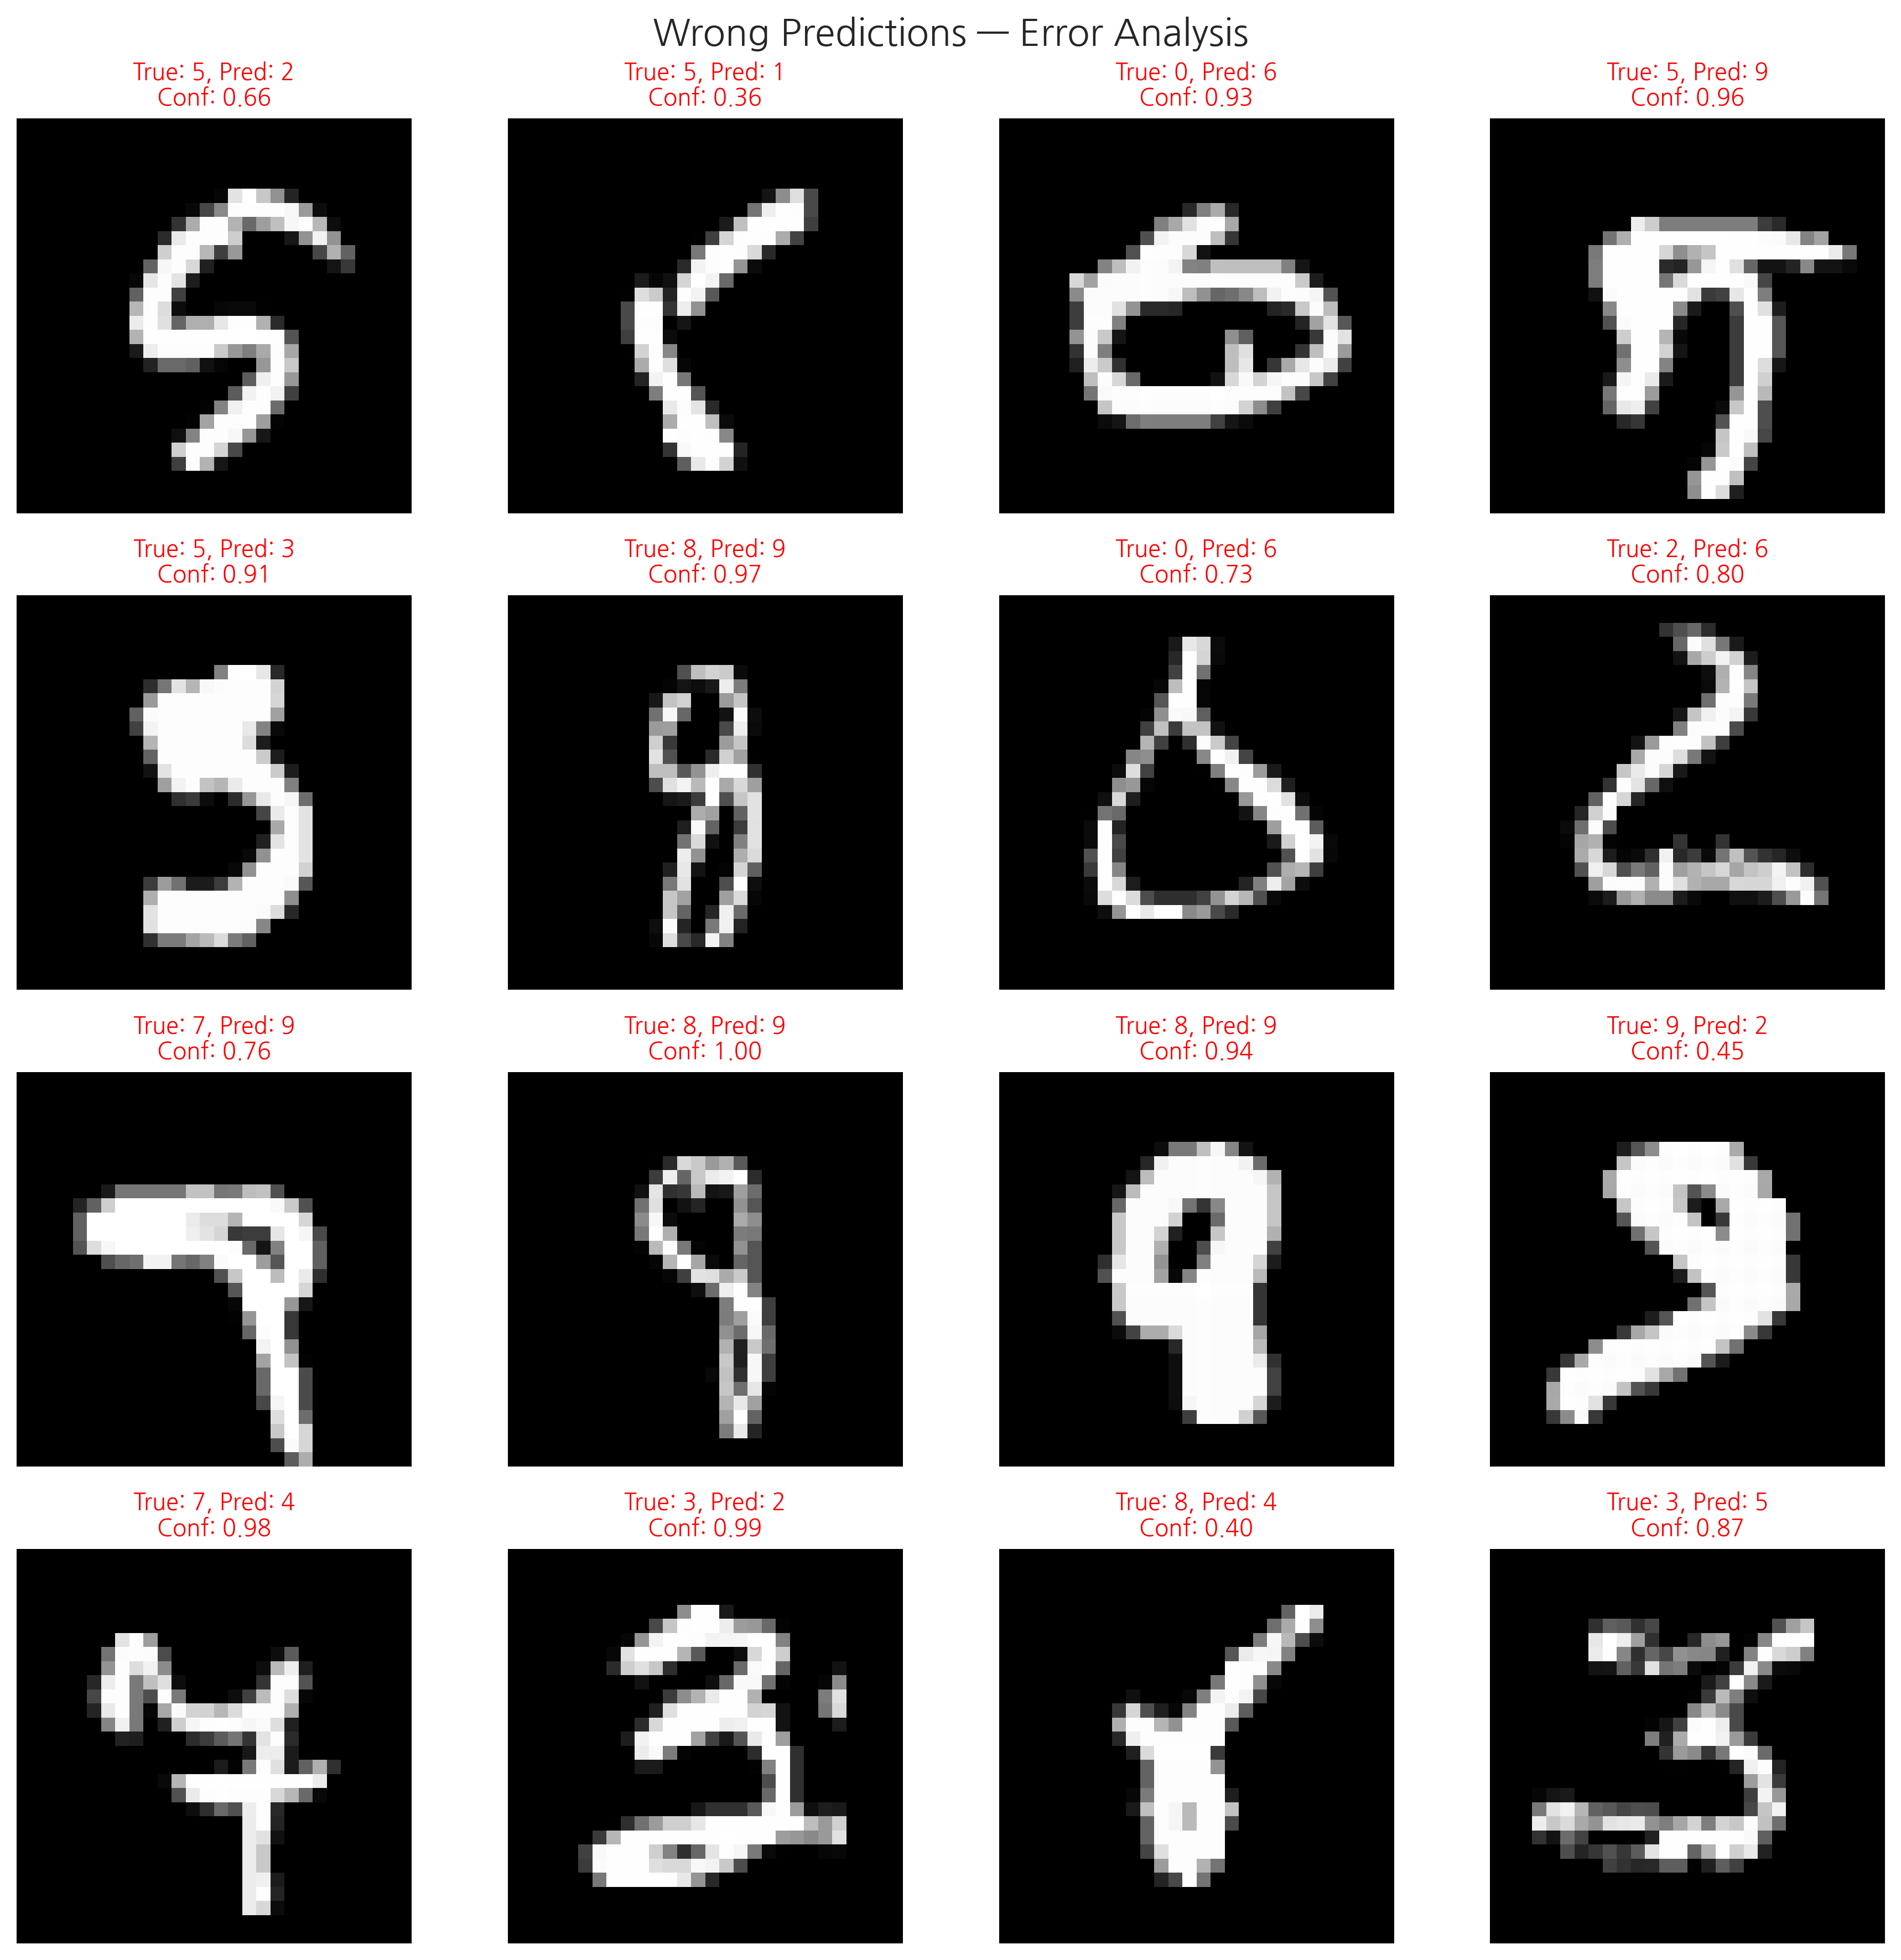

In [ ]:
# 틀린 이미지 시각화
if len(wrong_indices) > 0:
    n_show = min(16, len(wrong_indices))
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))

    for i in range(n_show):
        idx = wrong_indices[i]
        ax = axes[i // 4, i % 4]

        img = X_val[idx].reshape(28, 28)
        true_label = y_val[idx]
        pred_label = val_pred_labels[idx]
        confidence = val_predictions[idx, pred_label]

        ax.imshow(img, cmap='gray')
        ax.set_title(f'True: {true_label}, Pred: {pred_label}\n'
                     f'Conf: {confidence:.2f}',
                     color='red', fontweight='bold', fontsize=10)
        ax.axis('off')

    plt.suptitle('Wrong Predictions — Error Analysis',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('error_analysis.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    print("\n🎉 Perfect! No errors on validation set!")

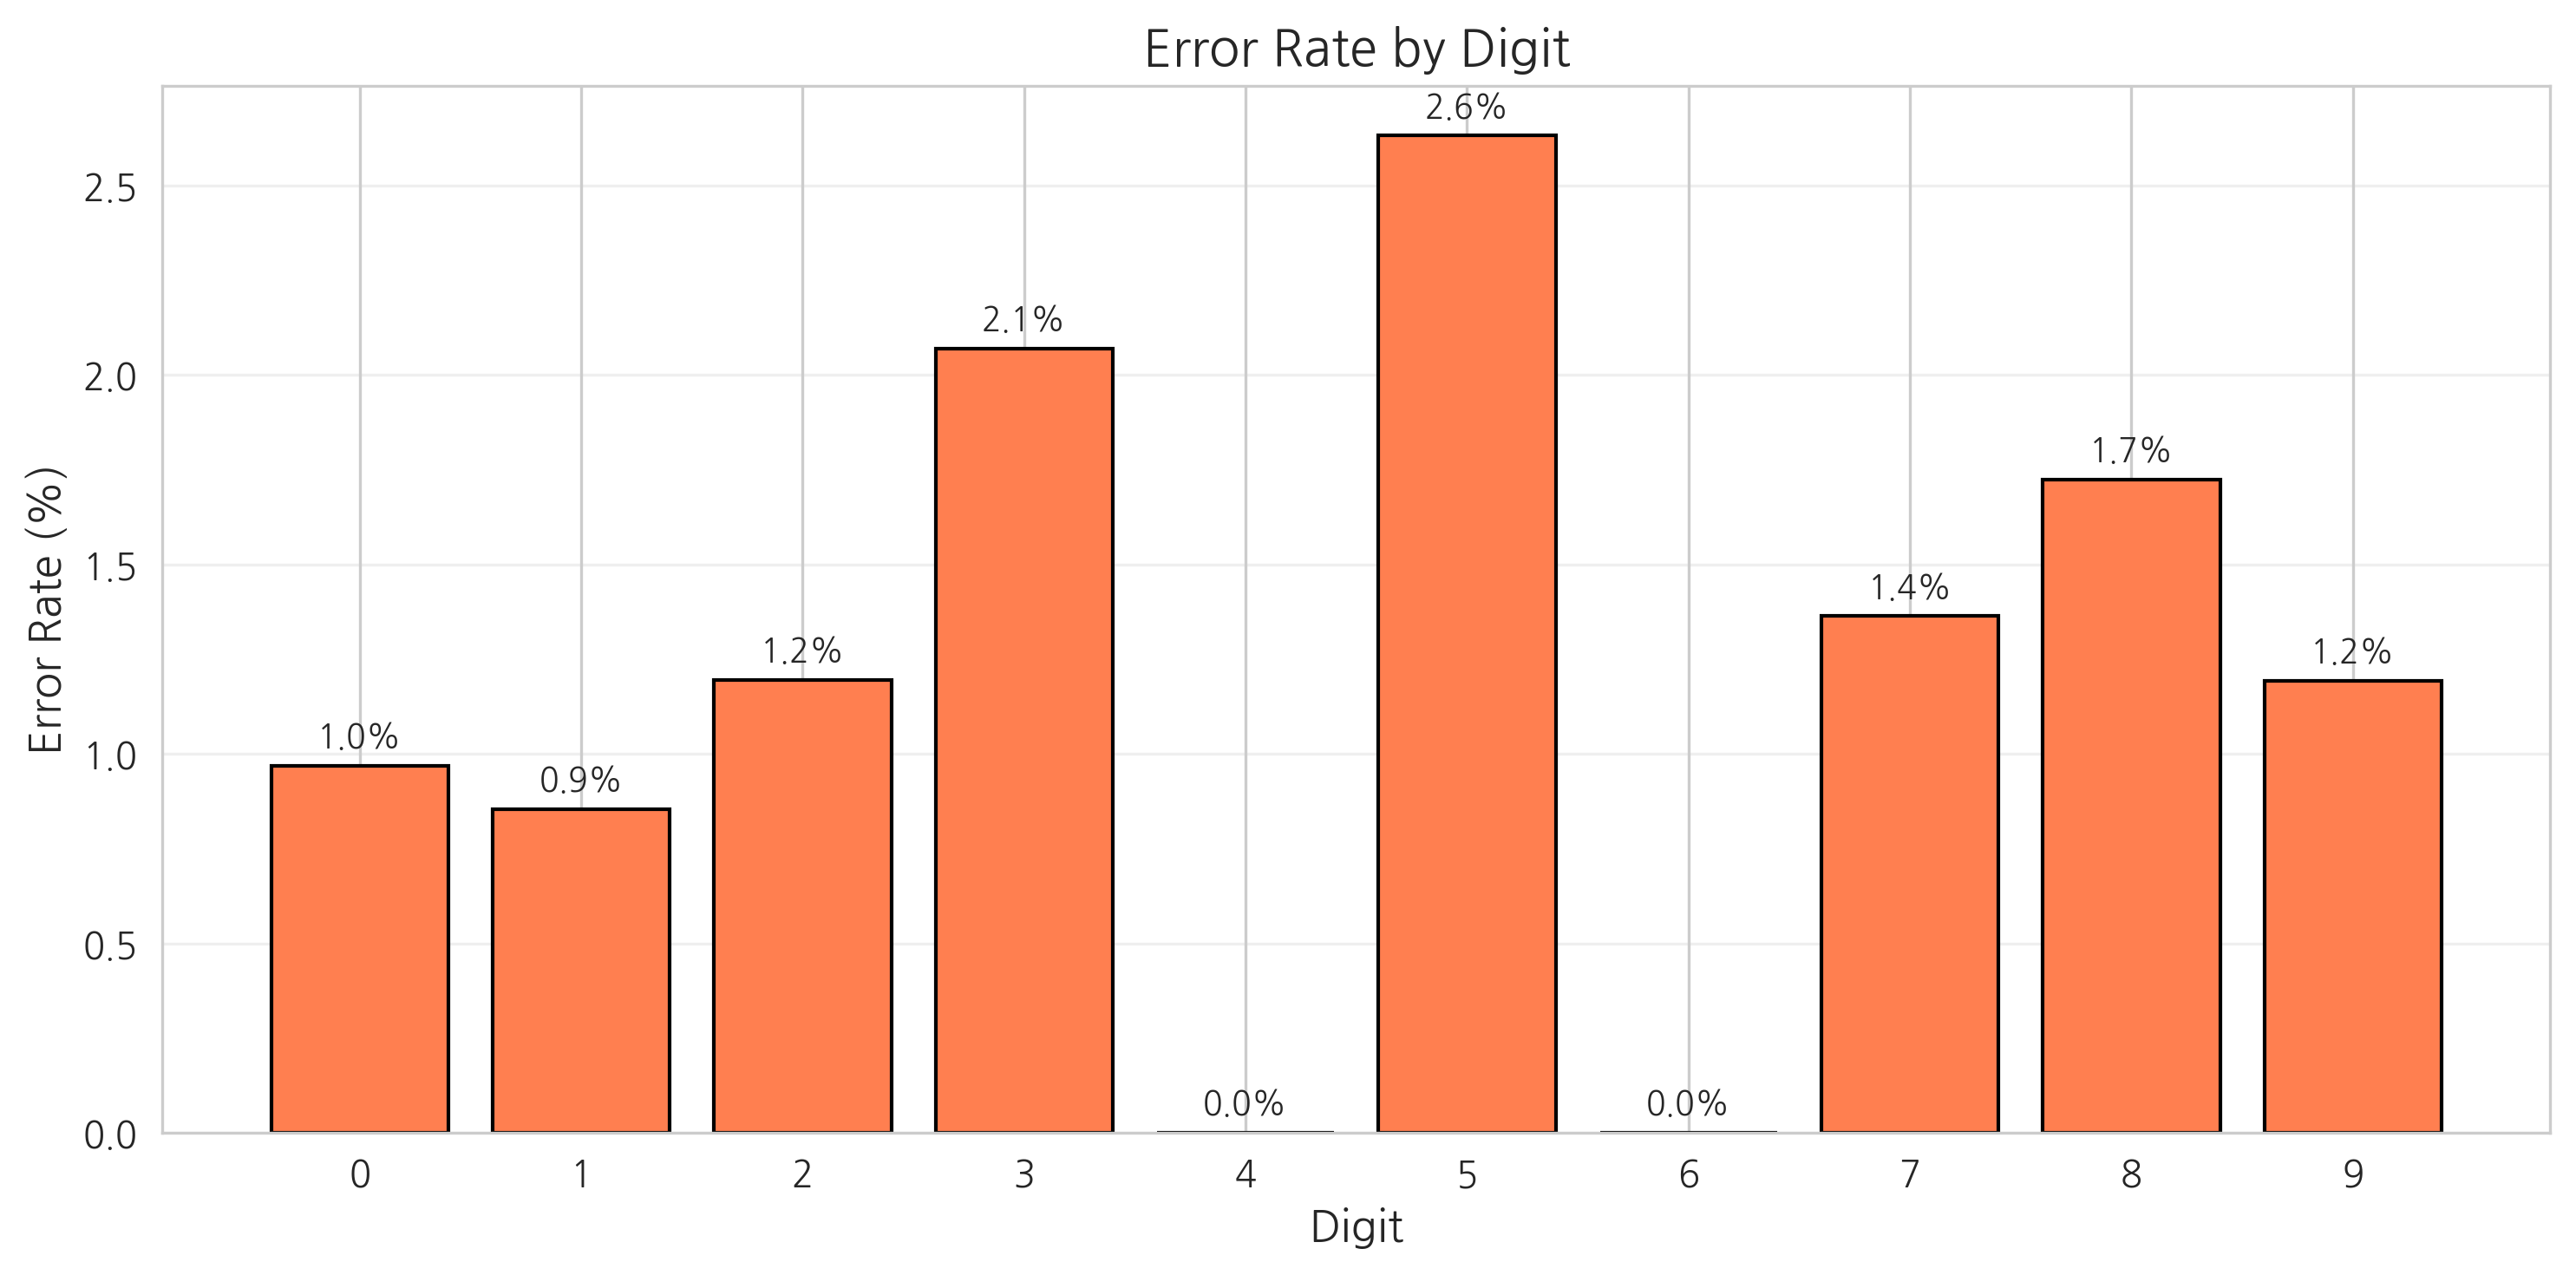


가장 흔한 혼동:
  5 → 6: 5번
  0 → 6: 4번
  8 → 9: 4번
  7 → 9: 3번
  3 → 5: 3번


In [ ]:
# 오류 패턴 분석
wrong_true_labels = y_val[wrong_indices]
wrong_pred_labels = val_pred_labels[wrong_indices]

# True label별 오류율
error_by_class = {}
for digit in range(10):
    total = np.sum(y_val == digit)
    errors = np.sum(wrong_true_labels == digit)
    error_by_class[digit] = errors / total * 100 if total > 0 else 0

# 시각화
plt.figure(figsize=(10, 5))
bars = plt.bar(error_by_class.keys(), error_by_class.values(), color='coral', edgecolor='black')
plt.xlabel('Digit', fontweight='bold', fontsize=12)
plt.ylabel('Error Rate (%)', fontweight='bold', fontsize=12)
plt.title('Error Rate by Digit', fontweight='bold', fontsize=14)
plt.xticks(range(10))
plt.grid(axis='y', alpha=0.3)

for digit, rate in error_by_class.items():
    plt.text(digit, rate + 0.05, f'{rate:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('error_by_digit.png', dpi=100, bbox_inches='tight')
plt.show()

# 가장 혼동하는 숫자 쌍
from collections import Counter
confusion_pairs = [(wrong_true_labels[i], wrong_pred_labels[i])
                   for i in range(len(wrong_indices))]
top_confusions = Counter(confusion_pairs).most_common(5)

print("\n가장 흔한 혼동:")
print("="*40)
for (true, pred), count in top_confusions:
    print(f"  {true} → {pred}: {count}번")
print("="*40)

## 📈 5. Confusion Matrix

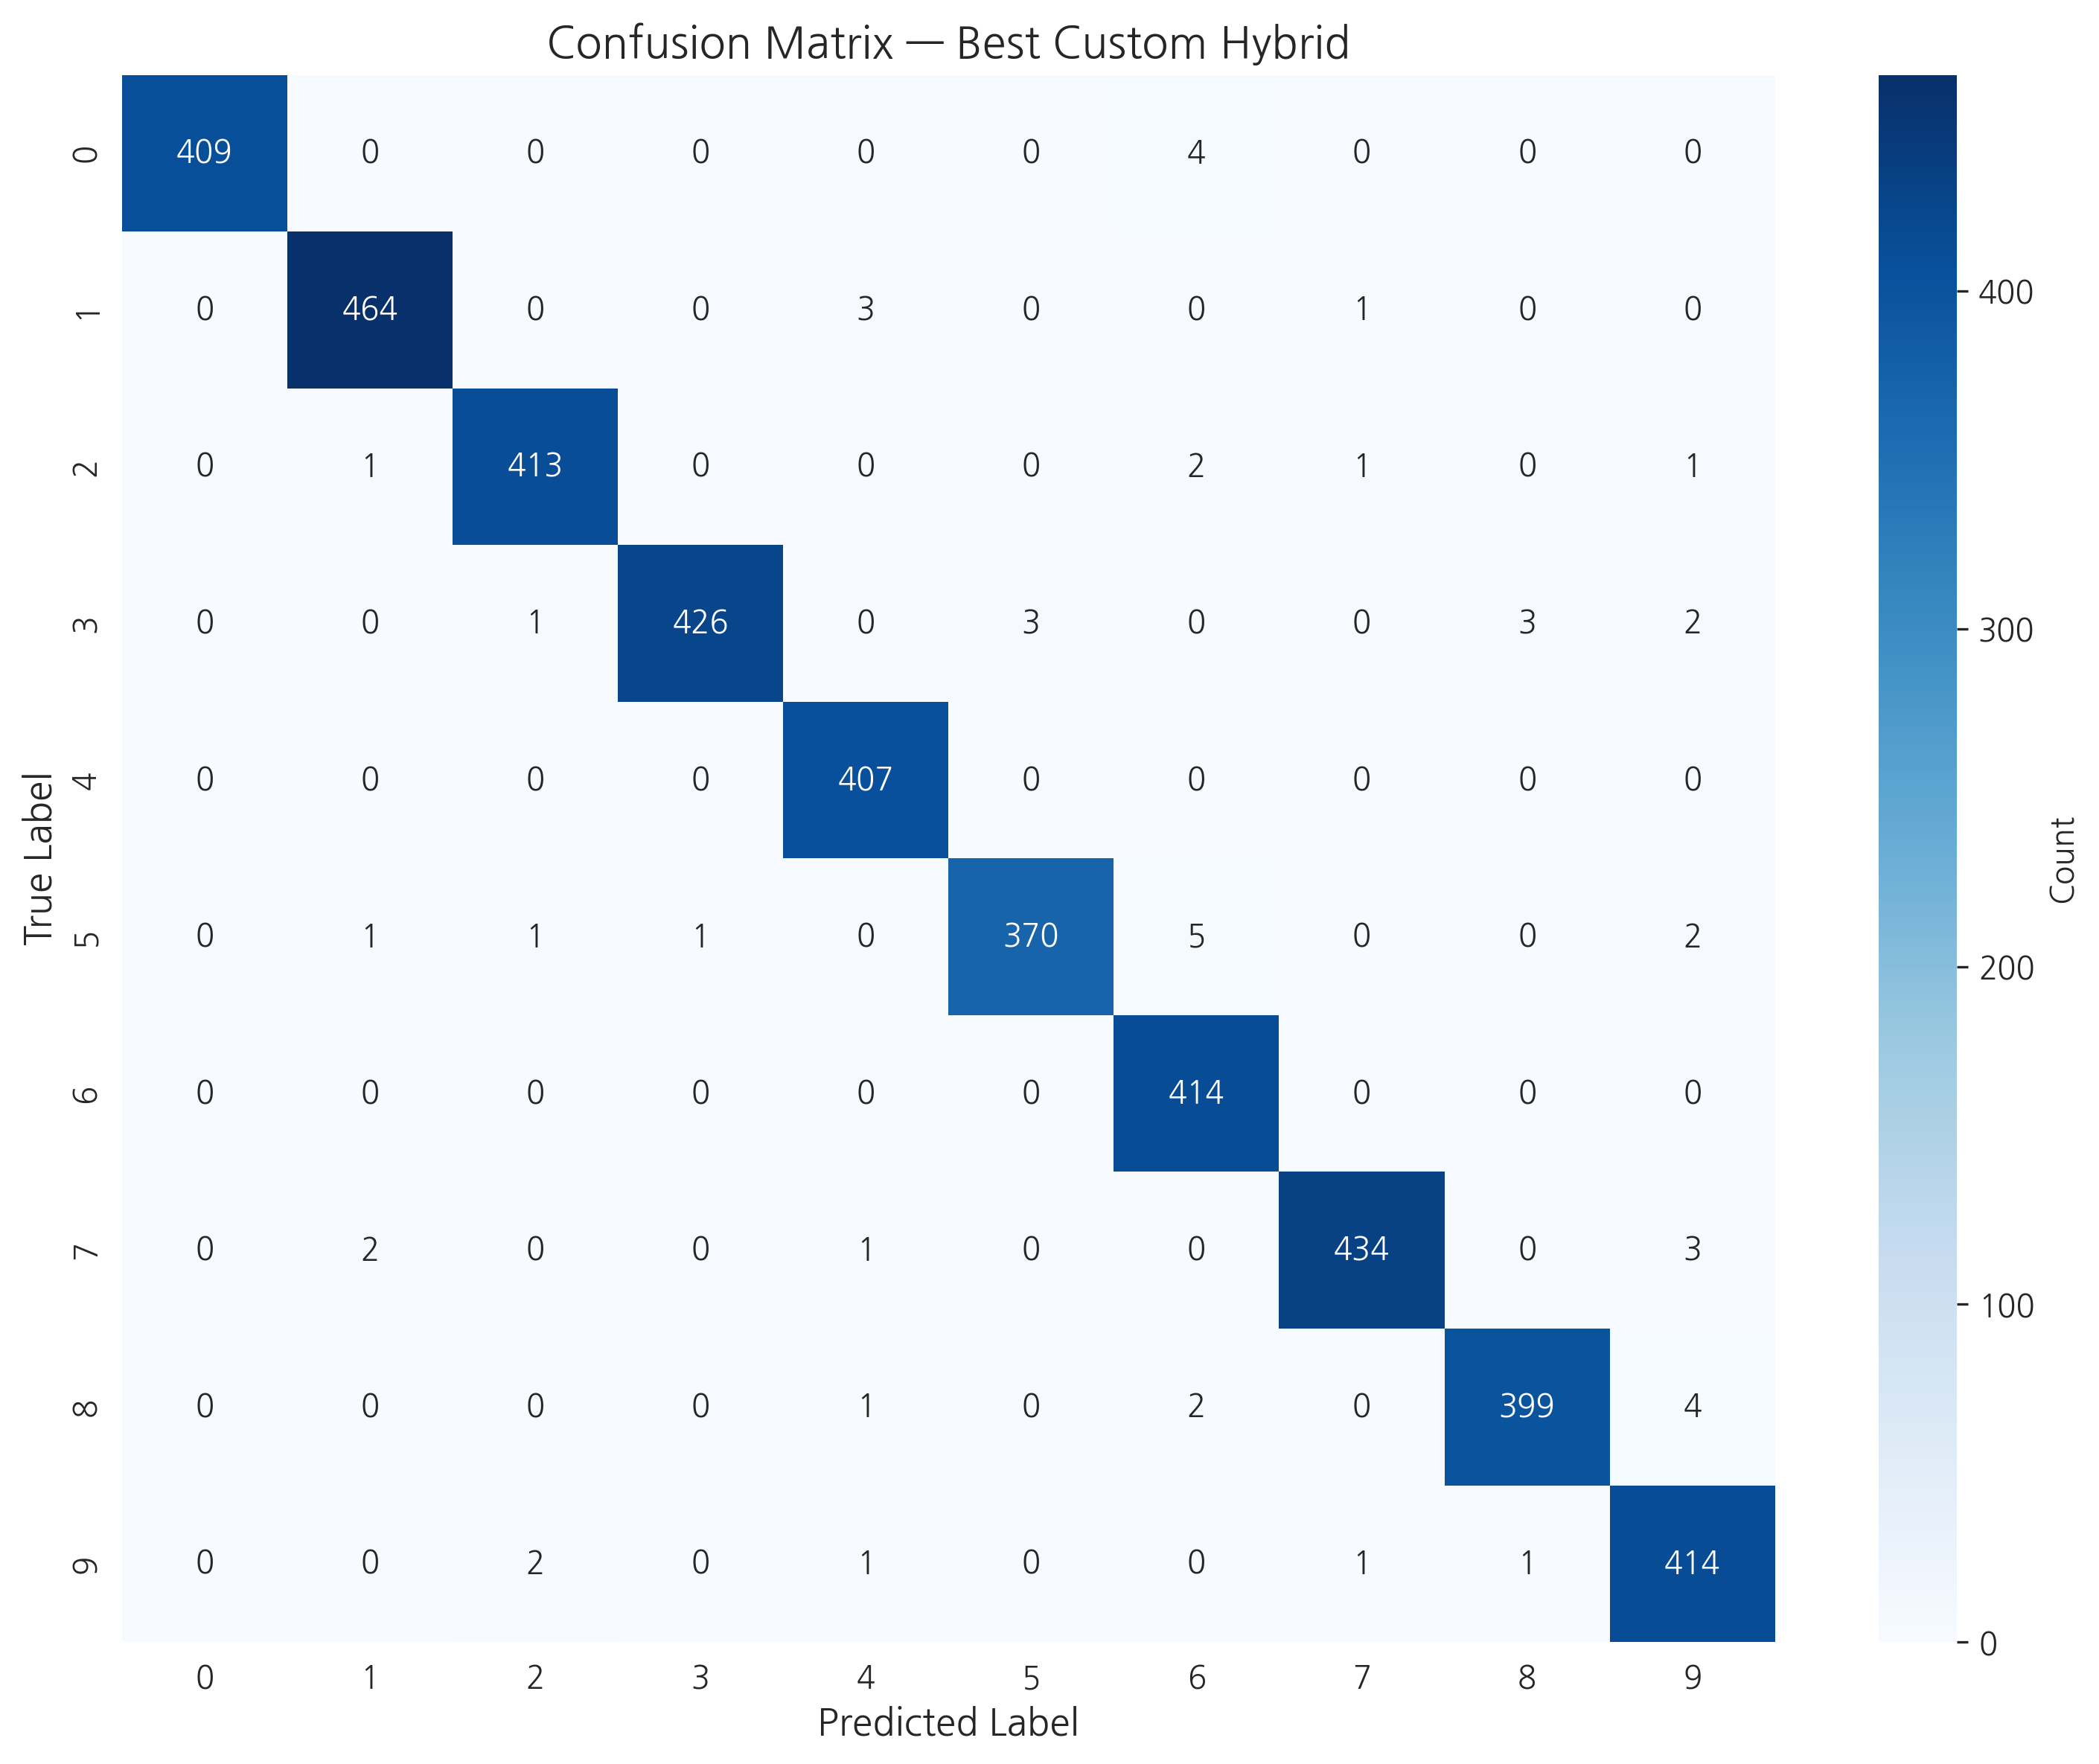

In [ ]:
# Confusion Matrix 계산
cm = confusion_matrix(y_val, val_pred_labels)

# 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10),
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontweight='bold', fontsize=12)
plt.ylabel('True Label', fontweight='bold', fontsize=12)
plt.title('Confusion Matrix — Best Custom Hybrid',
          fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

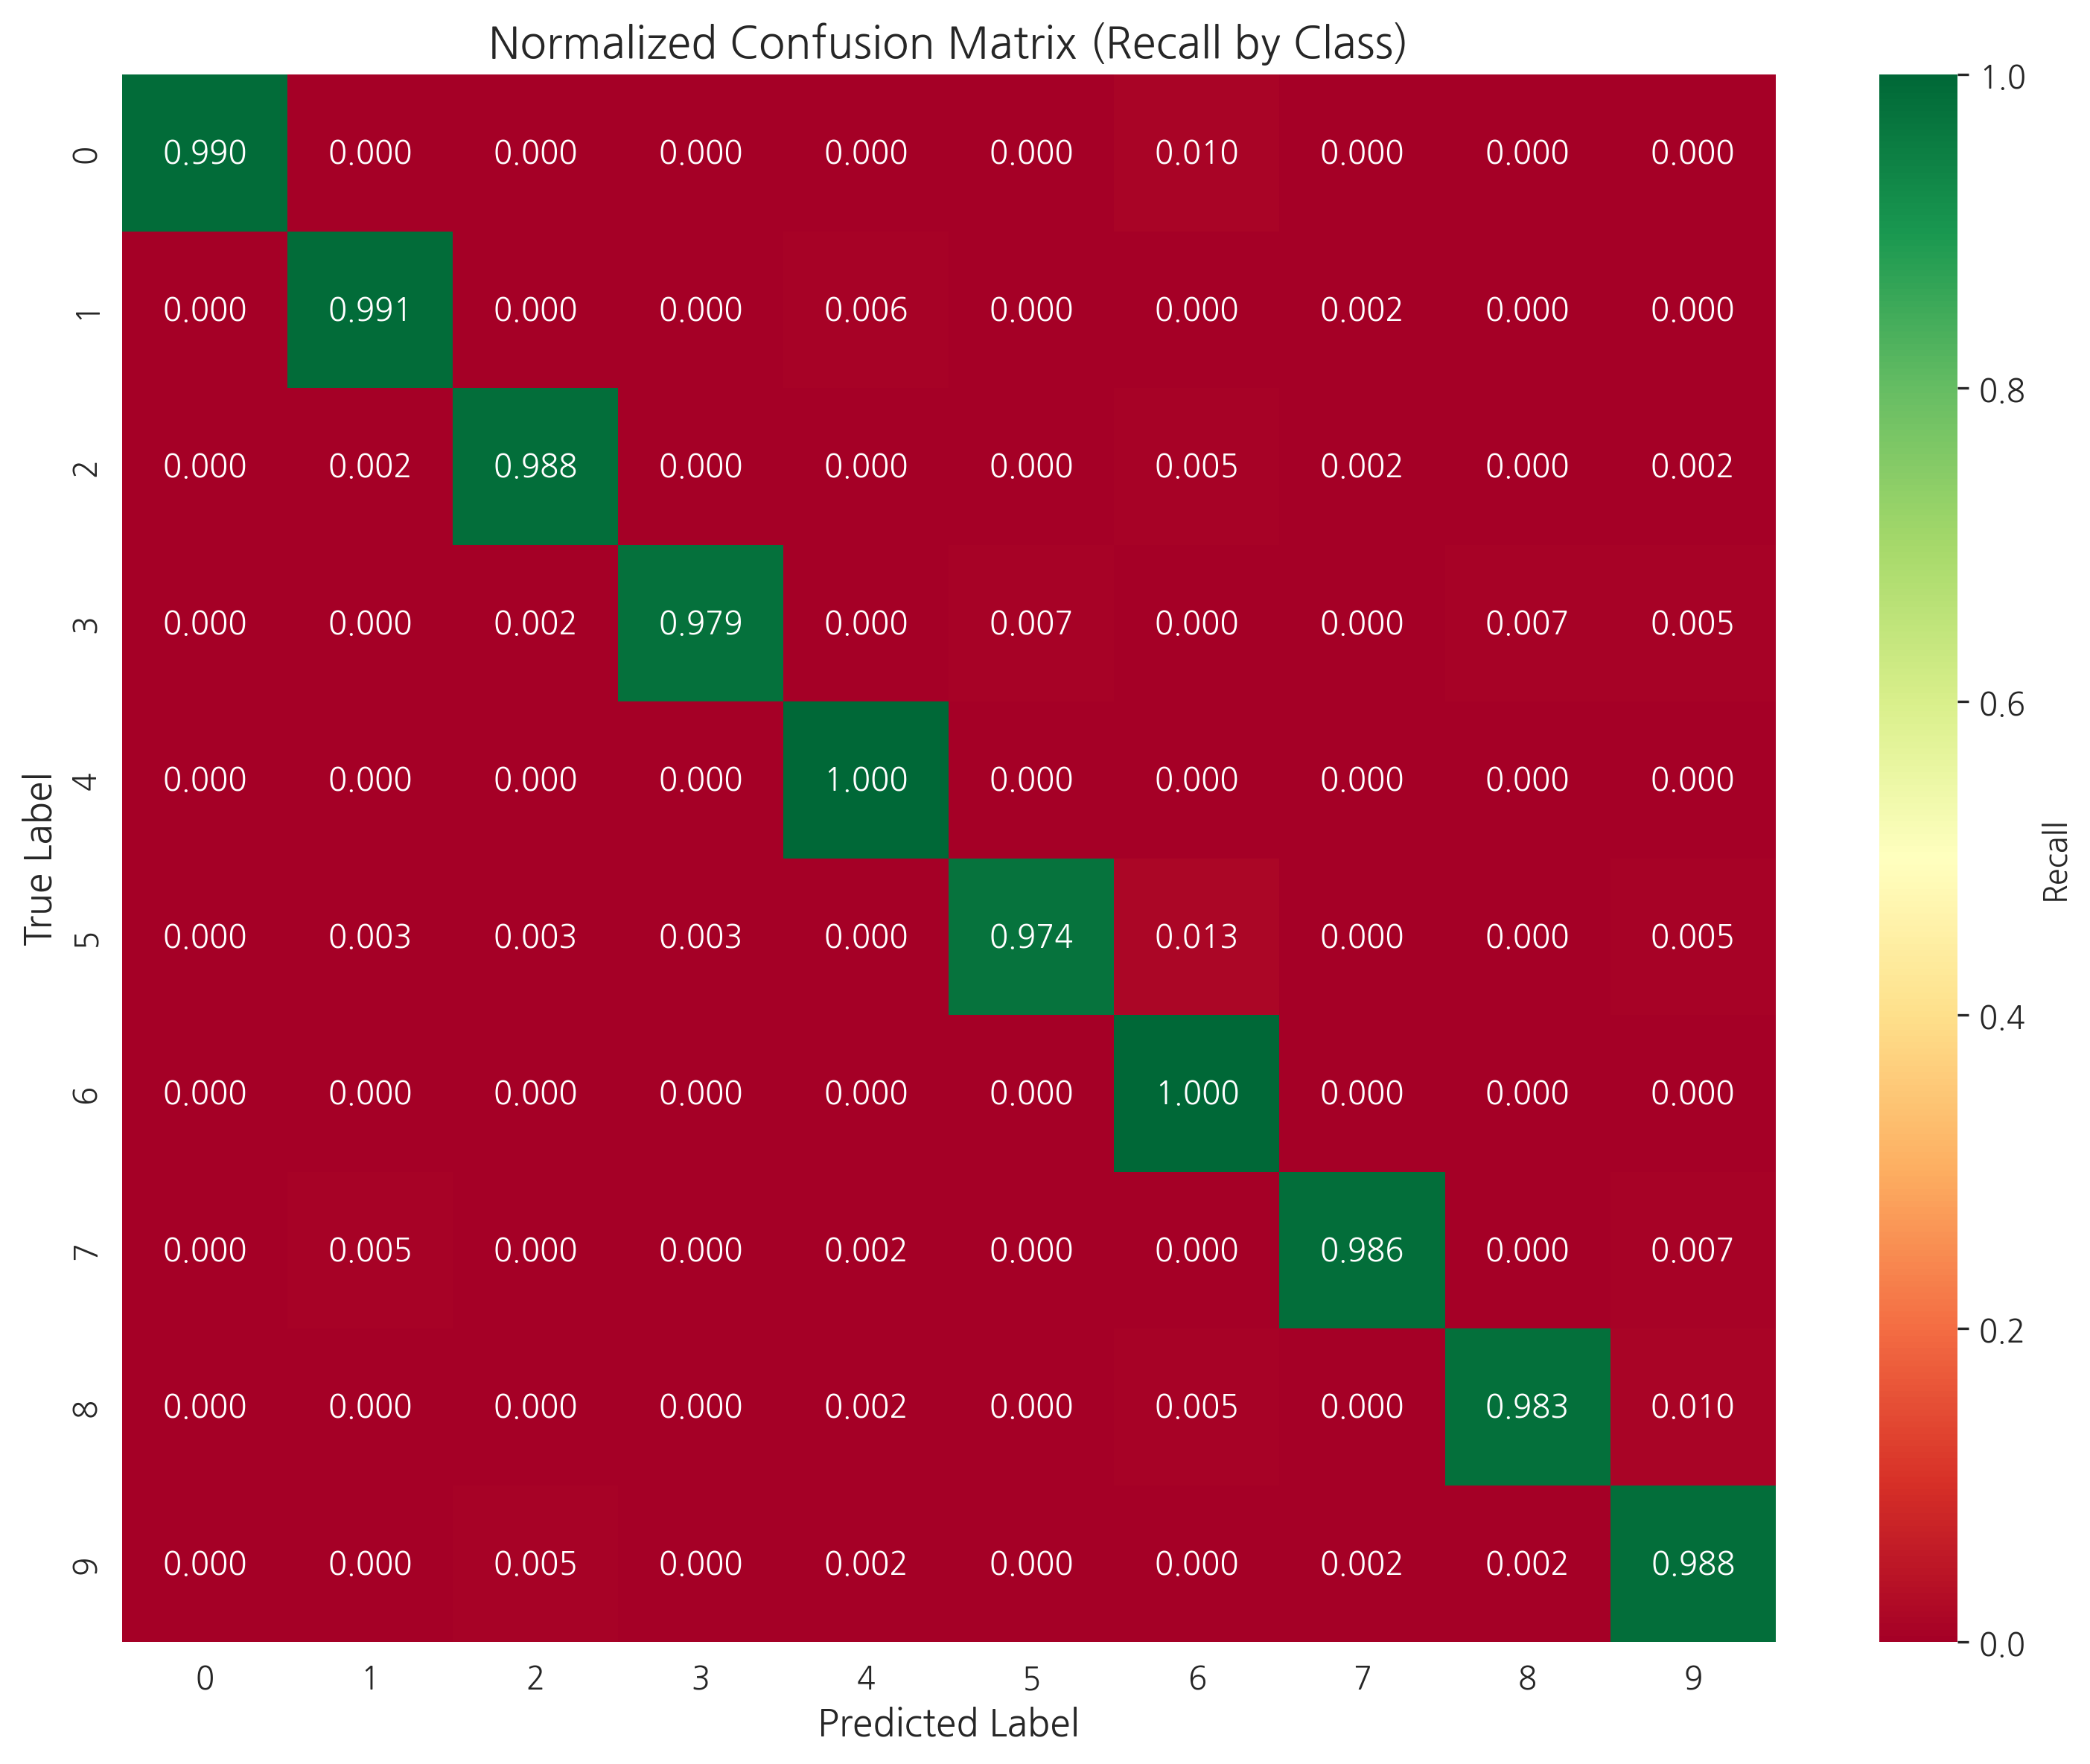


Per-class Recall:
  Digit 0: 0.9903 (99.03%)
  Digit 1: 0.9915 (99.15%)
  Digit 2: 0.9880 (98.80%)
  Digit 3: 0.9793 (97.93%)
  Digit 4: 1.0000 (100.00%)
  Digit 5: 0.9737 (97.37%)
  Digit 6: 1.0000 (100.00%)
  Digit 7: 0.9864 (98.64%)
  Digit 8: 0.9828 (98.28%)
  Digit 9: 0.9881 (98.81%)


In [ ]:
# Normalized Confusion Matrix (Recall)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='RdYlGn',
            xticklabels=range(10), yticklabels=range(10),
            vmin=0, vmax=1, cbar_kws={'label': 'Recall'})
plt.xlabel('Predicted Label', fontweight='bold', fontsize=12)
plt.ylabel('True Label', fontweight='bold', fontsize=12)
plt.title('Normalized Confusion Matrix (Recall by Class)',
          fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix_normalized.png', dpi=100, bbox_inches='tight')
plt.show()

# Per-class Recall
print("\nPer-class Recall:")
print("="*40)
for digit in range(10):
    recall = cm_normalized[digit, digit]
    print(f"  Digit {digit}: {recall:.4f} ({recall*100:.2f}%)")
print("="*40)

## 🔬 6. 심층 분석

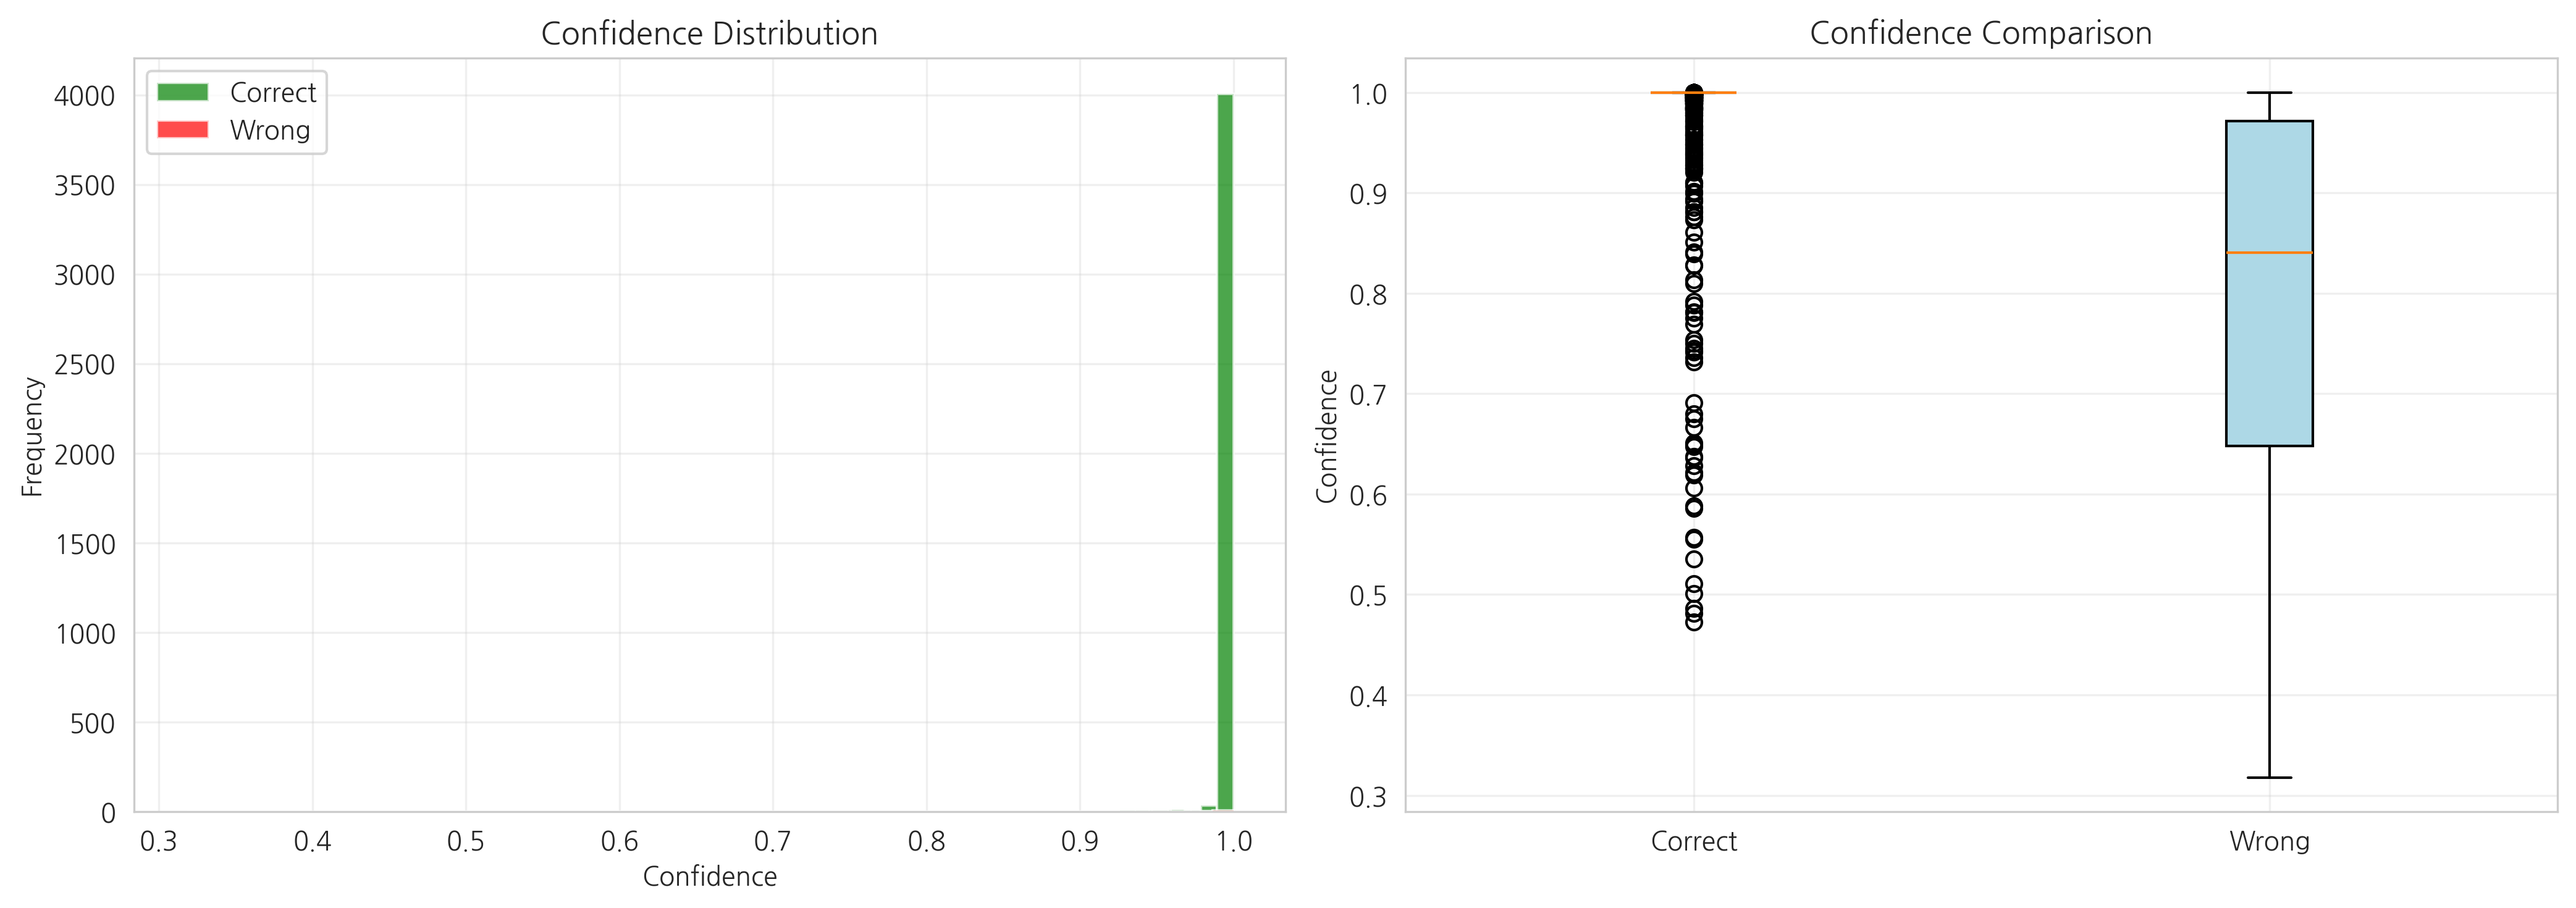


Confidence Statistics:
  Correct predictions - Mean: 0.9954
  Wrong predictions   - Mean: 0.7902


In [ ]:
# Confidence 분석
confidences = np.max(val_predictions, axis=1)

wrong_confidences = confidences[wrong_indices]
correct_indices = np.setdiff1d(range(len(y_val)), wrong_indices)
correct_confidences = confidences[correct_indices]

# 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(correct_confidences, bins=50, alpha=0.7, label='Correct', color='green')
axes[0].hist(wrong_confidences, bins=50, alpha=0.7, label='Wrong', color='red')
axes[0].set_xlabel('Confidence', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('Confidence Distribution', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot
axes[1].boxplot([correct_confidences, wrong_confidences],
                labels=['Correct', 'Wrong'], patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_ylabel('Confidence', fontweight='bold')
axes[1].set_title('Confidence Comparison', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('confidence_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nConfidence Statistics:")
print(f"  Correct predictions - Mean: {correct_confidences.mean():.4f}")
print(f"  Wrong predictions   - Mean: {wrong_confidences.mean():.4f}")


High Confidence Mistakes (Conf > 0.9): 20


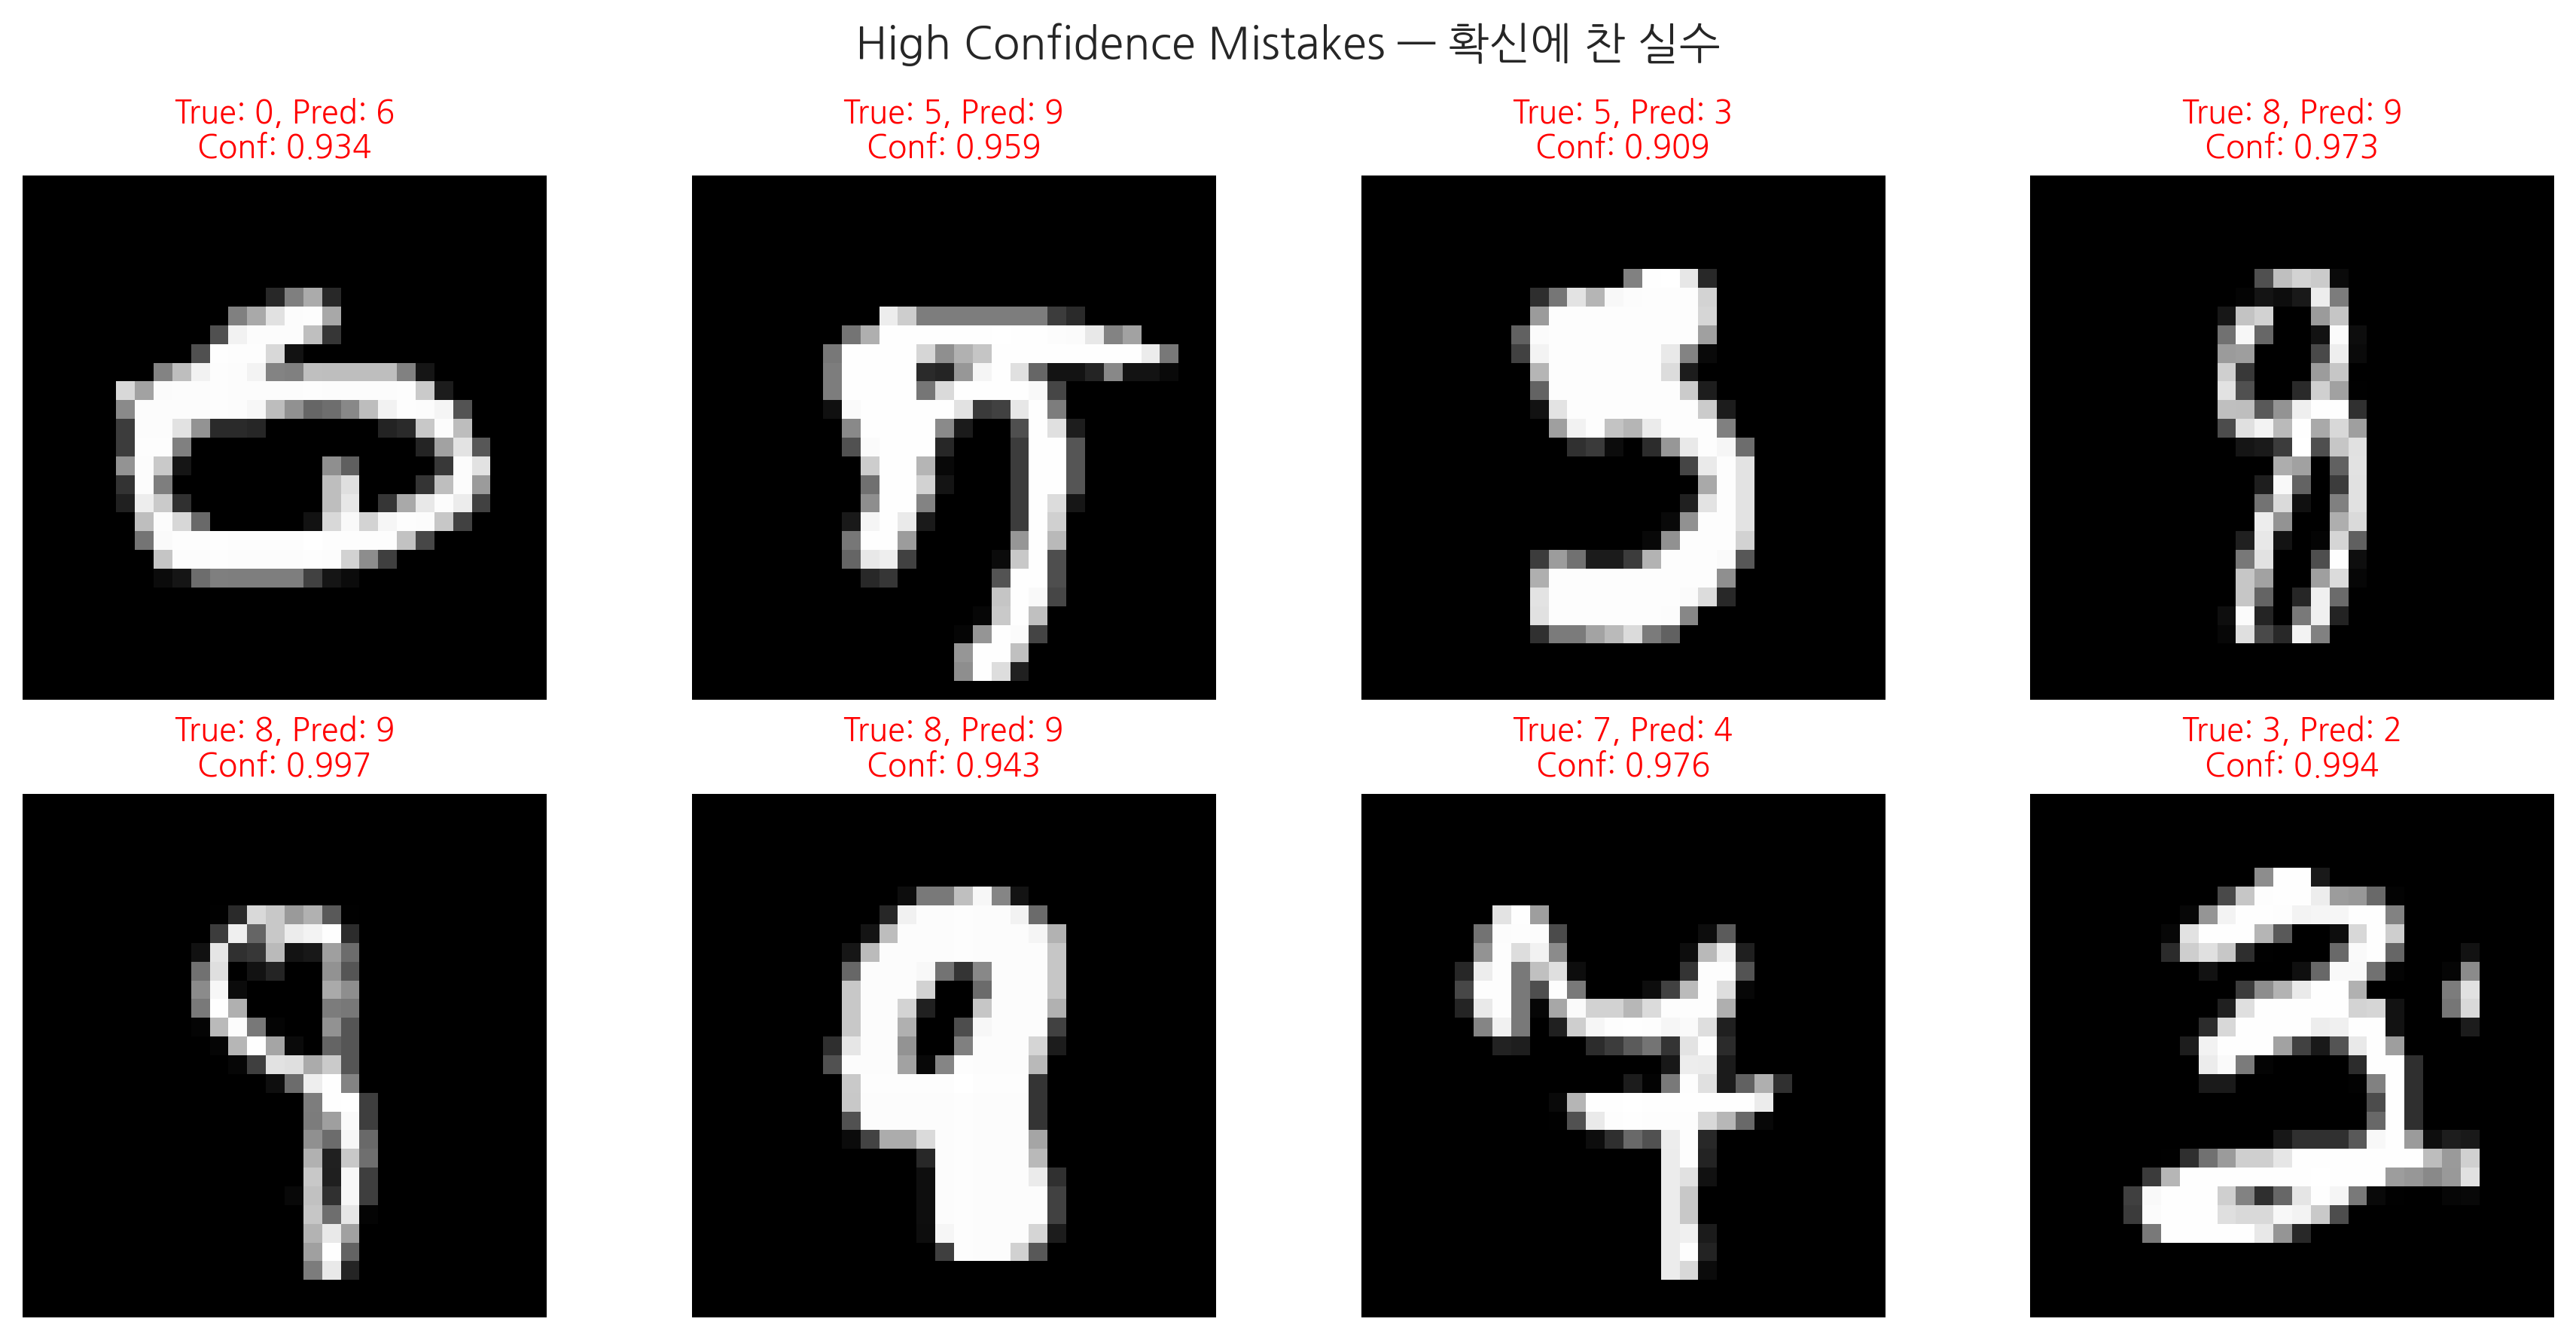

In [ ]:
# High confidence mistakes
high_conf_wrong = np.where((val_pred_labels != y_val) & (confidences > 0.9))[0]

print(f"\nHigh Confidence Mistakes (Conf > 0.9): {len(high_conf_wrong)}")

if len(high_conf_wrong) > 0:
    n_show = min(8, len(high_conf_wrong))
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))

    for i in range(n_show):
        idx = high_conf_wrong[i]
        ax = axes[i // 4, i % 4]

        img = X_val[idx].reshape(28, 28)
        true = y_val[idx]
        pred = val_pred_labels[idx]
        conf = confidences[idx]

        ax.imshow(img, cmap='gray')
        ax.set_title(f'True: {true}, Pred: {pred}\nConf: {conf:.3f}',
                     color='red', fontsize=10, fontweight='bold')
        ax.axis('off')

    plt.suptitle('High Confidence Mistakes — 확신에 찬 실수',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('high_conf_mistakes.png', dpi=100, bbox_inches='tight')
    plt.show()

## 💡 7. 개선 방향 도출

In [ ]:
# 개선 계획
improvement_plan = {
    '1. Data Augmentation': {
        'method': 'Rotation, Shift, Zoom',
        'expected': '+0.2~0.5%',
        'effort': 'Low',
        'priority': 'High'
    },
    '2. Ensemble': {
        'method': 'ResNet + Custom + VGG',
        'expected': '+0.3~0.7%',
        'effort': 'Medium',
        'priority': 'High'
    },
    '3. Test-Time Augmentation': {
        'method': '여러 번 augment → 평균',
        'expected': '+0.1~0.3%',
        'effort': 'Low',
        'priority': 'Medium'
    },
    '4. Learning Rate Schedule': {
        'method': 'Cosine Annealing',
        'expected': '+0.1~0.2%',
        'effort': 'Low',
        'priority': 'Medium'
    }
}

print("="*70)
print("  개선 계획")
print("="*70)
for name, details in improvement_plan.items():
    print(f"\n{name}")
    for key, value in details.items():
        print(f"  {key:12s}: {value}")
print("\n" + "="*70)

  개선 계획

1. Data Augmentation
  method      : Rotation, Shift, Zoom
  expected    : +0.2~0.5%
  effort      : Low
  priority    : High

2. Ensemble
  method      : ResNet + Custom + VGG
  expected    : +0.3~0.7%
  effort      : Medium
  priority    : High

3. Test-Time Augmentation
  method      : 여러 번 augment → 평균
  expected    : +0.1~0.3%
  effort      : Low
  priority    : Medium

4. Learning Rate Schedule
  method      : Cosine Annealing
  expected    : +0.1~0.2%
  effort      : Low
  priority    : Medium



## 📊 8. 최종 요약

In [ ]:
# Day 3 전체 요약
summary = {
    'Day 3-1': {'Model': 'Simple CNN', 'Val Acc': '98.0%', 'Note': 'Baseline'},
    'Day 3-2': {'Model': 'ResNet-style', 'Val Acc': '99.1%', 'Note': 'Best Architecture'},
    'Day 3-3': {'Model': 'Custom (Tuned)', 'Val Acc': '98.5%', 'Note': 'HPO Success'},
    'Day 3-4': {'Model': 'Best Model', 'Val Acc': f'{val_accuracy:.1%}', 'Note': 'Kaggle Submit'}
}

summary_df = pd.DataFrame(summary).T
print("="*70)
print("  Day 3 전체 요약")
print("="*70)
print(summary_df.to_string())
print("="*70)

print(f"\n✅ Kaggle Submission 완료!")
print(f"   Val Accuracy: {val_accuracy:.4f}")
print(f"   Expected Test: ~98.3-98.7%")
print(f"   Target Rank: Top 30%")
print("\n   Public Leaderboard에서 점수를 확인하세요!")

  Day 3 전체 요약
                  Model Val Acc               Note
Day 3-1      Simple CNN   98.0%           Baseline
Day 3-2    ResNet-style   99.1%  Best Architecture
Day 3-3  Custom (Tuned)   98.5%        HPO Success
Day 3-4      Best Model   98.8%      Kaggle Submit

✅ Kaggle Submission 완료!
   Val Accuracy: 0.9881
   Expected Test: ~98.3-98.7%
   Target Rank: Top 30%

   Public Leaderboard에서 점수를 확인하세요!


## ✅ Day 3-4 완료 체크리스트

- [ ] Best model 로드 완료
- [ ] Test set 예측 실행
- [ ] submission.csv 생성
- [ ] 파일 검증 통과 (크기, Label, ImageId)
- [ ] Kaggle 제출 (Web UI or API)
- [ ] Public Leaderboard 점수 확인
- [ ] Validation Error Analysis
- [ ] 틀린 이미지 시각화
- [ ] Confusion Matrix 생성
- [ ] Per-class Recall 확인
- [ ] Confidence 분석
- [ ] High confidence mistakes 분석
- [ ] 개선 방향 도출
- [ ] 최종 요약 완료

## 🎯 다음 단계 (Day 3-5)

**Day 3-5: 고급 기법 & 최종 최적화 (선택)**

**내용:**
1. Data Augmentation 적용
2. Ensemble 구축 (ResNet + Custom + VGG)
3. Test-Time Augmentation (TTA)
4. Learning Rate Scheduling
5. 최종 Kaggle 재제출
6. 순위 변화 확인

**목표:**
```
Current: ~98.5% (Top 30%)
Target:  ~99.0%+ (Top 10% 도전!)
```

**예상 소요시간**: 2-3시간

축하합니다! Day 3-4 완료 🎉